# Description du projet
L'objectif de ce modèle est de prédire la suite donnée à une personne physique ou morale donnée, au regard de ses caractéristiques intrinsèques. 
Pour cela, nous allons exploiter des outils de machine learning classique et de deep learning.  

Il est à noter que notre problème est donc un problème de classification multi classe, car il y a plusieurs possibilités, qui sont:  
  
-Loan originated(Prêt accordé)                                
-Loan purchased by the institution(Prêt acheté une autre institution financière)               
-Application withdrawn by applicant  (Demande retirée par le demandeur)             
-Application denied by financial institution   (Demande refusée par l'institution financière)  
-File closed for incompleteness(Dossier clos pour incomplétude)                 
-Application approved but not accepted(Demande approuvée mais non acceptée)  

Le dataset utilisé est un csv récueillie par une institution financière en Alaska(USA). Il n'existe pas de solution connue.  




# Accès à l'espace de développment du projet

[Cliquez ici pour accéder aux données.](https://raw.githubusercontent.com/Jomuel-net/AI-finance-project/refs/heads/main/Data%20set/data_bank_alaska.csv)  
[Cliquez ici pour accéder au github.](https://github.com/Jomuel-net/AI-finance-project/)


# Chargement et feature Engineering

## Importations

In [74]:
# importations sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, cross_val_score, validation_curve, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
import seaborn as sns

In [53]:
# importations pytorch
import torch
from torch.utils.data import TensorDataset, random_split, DataLoader                    
import torch.nn as nn 
from torch.nn import Module                                                            
import torch.optim as optim
from torch.optim import Optimizer
from torch.nn.modules.loss import _Loss
import torchmetrics
from torchmetrics import Metric


## Chargement des données

In [54]:
#récupération du dataset

dataset=pd.read_csv("https://raw.githubusercontent.com/Jomuel-net/AI-finance-project/refs/heads/main/Data%20set/data_bank_alaska.csv")


C:\Users\jomue\AppData\Local\Temp\ipykernel_25452\2755884230.py:3: DtypeWarning: Columns (36,38,46,48) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset=pd.read_csv("https://raw.githubusercontent.com/Jomuel-net/AI-finance-project/refs/heads/main/Data%20set/data_bank_alaska.csv")


In [55]:
# caractéristiques des données

head=dataset.head()
info=dataset.info()
print(head)
print(info)                                                                         # 28632 lignes et 78 colonnes, il y a trois types de données ( float, int and object=[string] )
target_name= "action_taken_name"                                                    
data , target = dataset.drop(columns=target_name), dataset[target_name]             # données à explorer et objectif

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28632 entries, 0 to 28631
Data columns (total 78 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   as_of_year                      28632 non-null  int64  
 1   respondent_id                   28632 non-null  object 
 2   agency_name                     28632 non-null  object 
 3   agency_abbr                     28632 non-null  object 
 4   agency_code                     28632 non-null  int64  
 5   loan_type_name                  28632 non-null  object 
 6   loan_type                       28632 non-null  int64  
 7   property_type_name              28632 non-null  object 
 8   property_type                   28632 non-null  int64  
 9   loan_purpose_name               28632 non-null  object 
 10  loan_purpose                    28632 non-null  int64  
 11  owner_occupancy_name            28632 non-null  object 
 12  owner_occupancy                 

### Stratégie d'exploration et amélioration du dataset 
Globalement, l'objectif était de supprimer les informations non utiles pour notre étude. Par exemplete, le numéro de l'agence (sachant que nous disposons déjà de son nom) , ou plus globalement toute représentation numérique d'une information littérale. Cela nous a permis de faire une réduction de dimension manuellement et de ne garder que les features intéressantes.  
Par suite, nous avons enlevé toutes les fautures qui avait plus de 30% de données manquantes (qui sera très utile pour l'apprentissage profond par la suite), toutes les lignes nulles et enfin les lignes dupliquées.
Pour finir, on a opté pour compléter certaines valeurs manquantes usuelles par respectivement la moyenne et le mode pour les features numériques et catégoriques.

In [56]:
# etude de la cible
print(pd.Series(target).value_counts())   # occurrences

action_taken_name
Loan originated                                14430
Loan purchased by the institution               6415
Application withdrawn by applicant              3495
Application denied by financial institution     3075
File closed for incompleteness                   756
Application approved but not accepted            461
Name: count, dtype: int64


In [62]:
#c. Feature Engineering
#Rien d'implémenter de connu pour faire ce que l'on doit faire. 
#Le gros du travail qui va être fait: 

#Lien nécessaire entre eric et jomuel
dataset = data

#Eléments à supprimer: 

#On va enlever les éléments qui ont des cases  vides dans: 
#C'est que ce sont des logements saisonniers/temporaires dans une zone de l'alaska sous sous peuplé.
#Que 75000 habitants sur plusieurs millions. 
#Sinon on perd des données c'est dommage et si on les remplace par des 0 cela risque de mal influencer notre modèle. 
#Car on perd plein d'autres données. 
#On enlève donc : ceux qui n'ont pas de county_code 
#et ceux qui n'ont pas:   applicant_income_000s
#On doit supprimer les éléments qui ont vide pour : applicant_income_000s et county_code 
#On crée L liste des éléments à supprimer:
L=[]
#pour county_code
#on va créer un dataset composé uniquement de county_code
#Basée sur la colonne "county_code": 
df_county = pd.DataFrame({"dataset county code":dataset["county_code"]})
#on va en récupérer toutes les lignes nulles
l_nulles_county = df_county.isnull().values.any()
#et les ajouter à L
L+=l_nulles_county
#pour applicant_income_000s
#on va créer un dataset composé uniquement de applicant_income_000s
#Basée sur la colonne "applicant_income_000s": 
df_income = pd.DataFrame({"dataset applicant_income_000s":dataset["applicant_income_000s"]})
#on va en récupérer toutes les lignes nulles
l_nulles_income = df_income.isnull().values.any()
#et les ajouter à L
L+=l_nulles_income
#suppression des lignes de notre liste:
dataset = dataset.drop(index=L)


#les colonnes dont nous devons nous occuper:

#les colonnes à supprimer: on va en récupérer les noms 
#on va récupérer les inutiles et celles qui forment des doublons. Par exemple on a des colonnes dont on a du data 
#categorical et ensuite sa transcription en numerical. On garde alors juste la transcription en numerical
#Les colonnes que l'on enlève et l'explication qui va avec: 
# Les inutiles
#la première: as_of_year, respondent_id,  state_abbr, state_code, hoepa_status, edit_status, sequence_number,
#application_date_indicator
dataset= dataset.drop(columns=["as_of_year", "respondent_id",  "state_abbr", "state_code", "hoepa_status", "edit_status", "sequence_number","agency_abbr","agency_code","state_name", "preapproval", "action_taken"])
#et aussi: 
#denial_reason_1, denial_reason_2, denial_reason_3 et rate_spread
#car beaucoup trop de données manquantes
dataset = dataset.drop(columns=["denial_reason_1", "denial_reason_2", "denial_reason_3", "rate_spread"])

#Toutes celles où l'on a la transposition en numerical ensuite:
#On garde toutes les colonnes qui sont en doublons avec les colonnes _name.
#Car on va toutes les traiter avec OneHotEncoder plus simplement
# On identifie toutes les colonnes qui finissent par "_name"
name_cols = [col for col in dataset.columns if col.endswith("_name")]
# On identifie alors toutes les colonnes qui correspondent sont les transpositions
#en numerical des colonnes qui finissent par name. 
radicals = [col[:-5] for col in name_cols]
# On récupère alors les numéros de colonnes auquels correspondent ces colonnes
cols_to_drop = [col for col in dataset.columns if col in radicals]

# >30%

# enleve les colonnes qui ont plus de 30% de données manquantes

pourcentage_manquant=dataset.isnull().mean()*100                                                                                               

colonnes_a_supprimer=pourcentage_manquant[pourcentage_manquant>30].index.tolist()                   

dataset=dataset.drop(columns=colonnes_a_supprimer)                                                  

# enelve toutes les lignes qui n'ont pas de features 
dataset.dropna(how="all")
#Et on enlève toutes ces colonnes
dataset=dataset.drop(columns=cols_to_drop)
#que nous n'ayons plus que des données numerical:
#On applique OneHotEncoder quand il faut. 
"""pour la race de l'applicant notamment: 
On va utiliser oneHotencoder
On ne va pas faire comme dans le dataset. On va créer 6 nouvelles features.
Car on a quand même plus de 500 personnes qui ont plus d'une race et puis cela est toujours bon de savoir comment faire. 
Et à chaque fois pour chaque données on va mettre un 1 ou 0 pour savoir si la donnée a cette race ou non. 
n avait tout coder à la main avant de découvrir one hot encoder. 
On fait pareil pour la race du co applicant. Mais cette fois ci avec 8 catégories. 
On ne va pas faire comme dans le dataset. On va créer 8 nouvelles features.
Car on a quand même plus de 150 personnes qui ont plus d'une race et puis cela est toujours bon de savoir comment faire. 
Et à chaque fois pour chaque données on va mettre un 1 ou 0 pour savoir si la donnée a cette race ou non. 
Et sinon bien sur on met un 1 dans notre provided. """

# enleve les lignes dupliquées
# doublons
dataset.duplicated().sum()                                                                       # nombre de dupliqués par ligne
dataset.drop_duplicates()                                                                        # enleve les dupliqués


#On sélectionne les numerical features
numerical_features=dataset.select_dtypes(include='number').columns.tolist()                         # stockage des données numériques (13 colonnes)
#On en déduit les categorical features
categorical_features=list(set(dataset.columns)-set(numerical_features))                             # stockage des données catégoriques(18 colonnes)


# enrichissement des données

dataset[numerical_features] = dataset[numerical_features].fillna(dataset[numerical_features].mean())                         # remplace les valeurs absentes par la moyenne de la colonne
dataset[categorical_features] = dataset[categorical_features].apply(lambda col: col.fillna(col.mode()[0]))                   # remplace la valeur absente par le mode 

#On va maintenant faire le preprocessing: 
#On définit la pipeline de preprocessing
numeric= StandardScaler()
categoric = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
preprocessor = ColumnTransformer(transformers=[("numeric",numeric, numerical_features),
("categoric",categoric, categorical_features)])


In [58]:
#Affichage du dataset
dataset                                                       

,agency_name,loan_type_name,property_type_name,loan_purpose_name,owner_occupancy_name,loan_amount_000s,preapproval_name,action_taken,msamd_name,county_name,...,applicant_income_000s,purchaser_type_name,hoepa_status_name,lien_status_name,population,minority_population,hud_median_family_income,tract_to_msamd_income,number_of_owner_occupied_units,number_of_1_to_4_family_units
0,Consumer Financial Protection Bureau,VA-guaranteed,One-to-four family dwelling (other than manufa...,Home purchase,Owner-occupied as a principal dwelling,359,Not applicable,1,Anchorage - AK,Matanuska-Susitna Borough,...,137.0,Ginnie Mae (GNMA),Not a HOEPA loan,Secured by a first lien,6702.000000,17.170000,89400.000000,94.010002,1651.000000,2219.000000
1,National Credit Union Administration,Conventional,One-to-four family dwelling (other than manufa...,Home purchase,Owner-occupied as a principal dwelling,99,Preapproval was not requested,1,Anchorage - AK,Anchorage Municipality,...,45.0,"Life insurance company, credit union, mortgage...",Not a HOEPA loan,Secured by a first lien,5868.442761,30.519685,86416.016269,106.829571,1421.434978,2109.775849
2,Consumer Financial Protection Bureau,FHA-insured,One-to-four family dwelling (other than manufa...,Home purchase,Owner-occupied as a principal dwelling,247,Not applicable,1,Fairbanks - AK,Fairbanks North Star Borough,...,64.0,Ginnie Mae (GNMA),Not a HOEPA loan,Secured by a first lien,11450.000000,20.030001,84800.000000,99.690002,2923.000000,3992.000000
3,National Credit Union Administration,Conventional,One-to-four family dwelling (other than manufa...,Home purchase,Owner-occupied as a principal dwelling,292,Not applicable,1,Anchorage - AK,Matanuska-Susitna Borough,...,120.0,"Commercial bank, savings bank or savings assoc...",Not a HOEPA loan,Secured by a first lien,3864.000000,22.490000,89400.000000,71.989998,979.000000,1328.000000
4,Federal Deposit Insurance Corporation,Conventional,One-to-four family dwelling (other than manufa...,Home purchase,Owner-occupied as a principal dwelling,589,Not applicable,1,Anchorage - AK,Anchorage Municipality,...,125.0,"Life insurance company, credit union, mortgage...",Not a HOEPA loan,Secured by a first lien,1941.000000,56.880001,89400.000000,58.340000,179.000000,318.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28627,Department of Housing and Urban Development,Conventional,One-to-four family dwelling (other than manufa...,Refinancing,Owner-occupied as a principal dwelling,341,Not applicable,1,Anchorage - AK,Anchorage Municipality,...,72.0,Freddie Mac (FHLMC),Not a HOEPA loan,Secured by a first lien,6017.000000,22.520000,89400.000000,119.639999,1470.000000,1908.000000
28628,Department of Housing and Urban Development,Conventional,One-to-four family dwelling (other than manufa...,Refinancing,Not owner-occupied as a principal dwelling,80,Not applicable,3,Anchorage - AK,Anchorage Municipality,...,160.0,Loan was not originated or was not sold in cal...,Not a HOEPA loan,Secured by a first lien,6017.000000,22.520000,89400.000000,119.639999,1470.000000,1908.000000
28629,Department of Housing and Urban Development,VA-guaranteed,One-to-four family dwelling (other than manufa...,Refinancing,Owner-occupied as a principal dwelling,199,Not applicable,1,Anchorage - AK,Aleutians West Census Area,...,64.0,Ginnie Mae (GNMA),Not a HOEPA loan,Secured by a first lien,4619.000000,71.339996,78400.000000,130.669998,213.000000,680.000000
28630,Consumer Financial Protection Bureau,Conventional,One-to-four family dwelling (other than manufa...,Home purchase,Owner-occupied as a principal dwelling,280,Not applicable,1,Anchorage - AK,Aleutians West Census Area,...,138.0,Fannie Mae (FNMA),Not a HOEPA loan,Secured by a first lien,4619.000000,71.339996,78400.000000,130.669998,213.000000,680.000000


### Etude de la corrélation des caractéristiques numériques

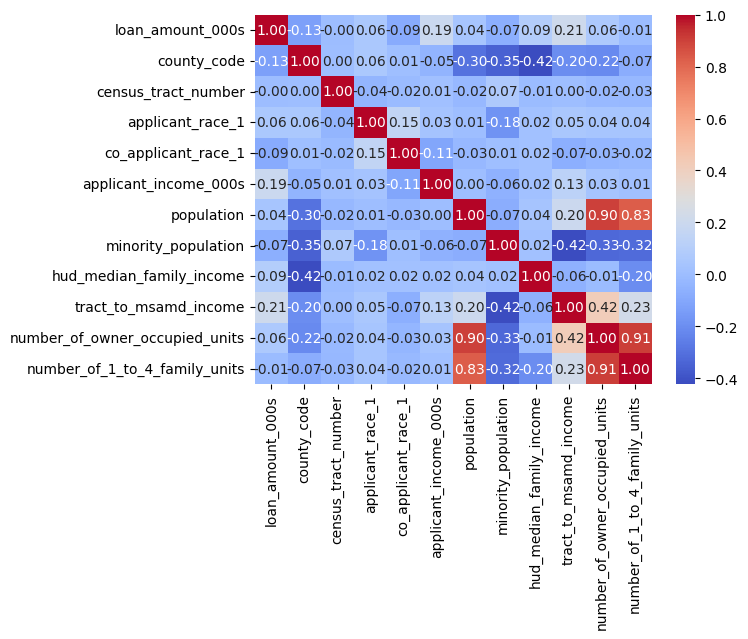

In [ ]:
# carte des températures 
corr_matrix = dataset[numerical_features].corr(method="pearson")                         # on a choisi la méthode de Pearson ( pour étudier la linéarité)
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

#### On peut donc noter que nous avons des corrélations très faibles entre variables numériques, Ainsi, on n'a pas à une dependance linéaire entre les variables, donc on n'exploitera pas de modèle linéaire.

### Etude de la distribution des caractéristiques

In [ ]:
# statistiques descriptives des varibles numériques
dataset[numerical_features].describe()


,loan_amount_000s,county_code,census_tract_number,applicant_race_1,co_applicant_race_1,applicant_income_000s,population,minority_population,hud_median_family_income,tract_to_msamd_income,number_of_owner_occupied_units,number_of_1_to_4_family_units
count,28632.000000,28632.000000,28632.000000,28632.000000,28632.000000,28632.000000,28632.000000,28632.000000,28632.000000,28632.000000,28632.000000,28632.000000
mean,251.157341,85.387301,14.868950,4.830190,6.628947,105.447980,5868.442761,30.519685,86416.016269,106.829571,1421.434978,2109.775849
std,187.179670,67.019929,166.677613,1.376852,1.751591,122.339622,2246.564602,16.139276,4507.129020,26.796332,657.408173,936.330502
min,1.000000,13.000000,1.000000,1.000000,1.000000,1.000000,643.000000,5.390000,78400.000000,41.299999,0.000000,76.000000
25%,169.000000,20.000000,4.010000,5.000000,5.000000,64.000000,4532.000000,18.730000,84800.000000,89.879997,963.000000,1522.000000
50%,234.000000,90.000000,9.020000,5.000000,8.000000,93.000000,5680.000000,25.320000,89400.000000,105.209999,1364.000000,1901.000000
75%,313.000000,150.000000,18.010000,5.000000,8.000000,117.000000,6707.000000,40.369999,89400.000000,120.500000,1739.000000,2483.000000
max,18514.000000,290.000000,9401.000000,7.000000,8.000000,12650.000000,11668.000000,97.959999,89400.000000,200.669998,3279.000000,5683.000000


### Stratégie de modèle de base

Nous avons opté pour un RandomForestClassifier parce que cest un modèle d'ensembke les plus éfficaces que nous rencontré durant ce cours. De prime abord, nous l'avons sans contrainte, puis avons une méthode de régularisation

# Modèle de base
Notons que la validation repose sur la cv

In [72]:
# model pipeloine and scaling complete
model_pipeline_full=Pipeline([ 
    ('preprocessor', preprocessor),
    ('rfc', RandomForestClassifier())
])

# data preparation
X_full=dataset[numerical_features+categorical_features]
Y= target

# training
model_pipeline_full.fit(X_full,Y)

# predictive model
y_pred=model_pipeline_full.predict(X_full)

# evaluation of the model using cross validation

cv_results= cross_validate(
    model_pipeline_full,
    X_full,
    Y,
    cv=StratifiedKFold(n_splits=10),
    scoring= 'accuracy',
    return_train_score= True,
    return_estimator= True
)
# print the accuracy
mean_accuracy_full_train = cv_results['train_score'].mean()
mean_accuracy_full_test = cv_results['test_score'].mean()

print(f"Accuracy_full_train  (10-fold CV) : {mean_accuracy_full_train:.2f}")

print(f"Accuracy_full_test  (10-fold CV) : {mean_accuracy_full_test:.2f}")

Accuracy_full_train  (10-fold CV) : 1.00
Accuracy_full_test  (10-fold CV) : 0.82


#### le score de train(1) étant très supérieur à celui du test(0.82), cela signifie que le modèle a surappris des données: ainsi, on applique une régularisation 

In [75]:
#Procédons en limitant la compléxité des arbres( par exemple la profondeur maximale et nombre d'estimateurs) 
# cherchons l'optimal grâce à la grid search
param_grid = {
    "rfc__n_estimators": [100, 200, 300],
    "rfc__max_depth": [5, 10, 15],
    "rfc__min_samples_split": [2, 5, 10],
    "rfc__min_samples_leaf": [1, 2, 4],
    "rfc__max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(model_pipeline_full, param_grid, cv=10, scoring="accuracy")
grid_search.fit(X_full, Y)

print("Best params:", grid_search.best_params_)


KeyboardInterrupt: 

In [ ]:
# on réentraine ainsi le modèle avec ses paramètres
model_pipeline_full=Pipeline([ 
    ('preprocessor', preprocessor),
    ('rfc', RandomForestClassifier())
])

# data preparation
X_full=dataset[numerical_features+categorical_features]
Y= target

# training
model_pipeline_full.fit(X_full,Y)

# predictive model
y_pred=model_pipeline_full.predict(X_full)

# evaluation of the model using cross validation

cv_results= cross_validate(
    model_pipeline_full,
    X_full,
    Y,
    cv=StratifiedKFold(n_splits=10),
    scoring= 'accuracy',
    return_train_score= True,
    return_estimator= True
)
# print the accuracy
mean_accuracy_full_train = cv_results['train_score'].mean()
mean_accuracy_full_test = cv_results['test_score'].mean()

print(f"Accuracy_full_train  (10-fold CV) : {mean_accuracy_full_train:.2f}")

print(f"Accuracy_full_test  (10-fold CV) : {mean_accuracy_full_test:.2f}")

### Conclusion intermédiaire
On obtient ainsi un modèle beaucoup plus stable capable de mieux généraliser sur les données non perçues (car score_train vaut presque score_test).  
Par suite, nous avons jugé utile de deployer un modèle d'apprentissage qui dans sa structure apprend de manière beaucoup plus stratégique qu'un modèle de machine learning classique. Nous avons mis en place un MLP  aussi assez classique à couches séquentielles. 

# Modèle de deep learning 

Let's Build and train a classification MLP on our data  with pytorch tools.

Let's Load the dataset using sklearn and create a custom PyTorch Dataset for this data.

In [ ]:
# implementation of the MLP

encoder=LabelEncoder()                                                                  # instance encoder
target_encoded=encoder.fit_transform(target)                                            # target encoding for tensor management

X_prepared=preprocessor.fit_transform(X_full)                                           # prepares X_full for pytorch( in numpy)

X=torch.tensor(X_prepared,dtype=torch.float32)                                          # data tensor building

means = X.mean(dim=0, keepdim=True)                                                     # mean
stds = X.std(dim=0, keepdim=True)                                                       # standard deviation(sigma)
 
stds[stds == 0] = 1.0                                                                   # avoid the 0-division 

X_standardized= (X - means) / stds                                                      # scaling

y=torch.tensor(target_encoded, dtype=torch.long)                                        # target tensor building                                           

data_set_torch=TensorDataset(X_standardized,y)                                          # data set building 

sample0, target0 = data_set_torch[0]
print (sample0.shape, target0.shape)                                                   

torch.Size([112]) torch.Size([])



Let's Create data loaders for training, validation, and testing.

In [ ]:
torch.manual_seed(42)

# define sizes for each step of the learning
train_size=len(data_set_torch)*80//100
valid_size=len(data_set_torch)*20//100
test_size=len(data_set_torch) - (train_size + valid_size)
train_dataset, valid_dataset , test_dataset = random_split(           
                                data_set_torch,
                                [train_size,valid_size,test_size]
                                ) 
# data loaders (to load data)
batch_size=32                                       # because it's a cpu
train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
valid_loader=DataLoader(valid_dataset,batch_size=batch_size)
test_loader=DataLoader(test_dataset,batch_size=batch_size)


 Let's build a custom MLP module to tackle our classification task

In [ ]:
# let's start by the sequential way (most obvious)
X_tensor, y_tensor=data_set_torch.tensors
n_inputs= X_tensor.shape[1]
n_classes= len(torch.unique(y_tensor))                      # number of differents categories to predict  
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# set the model
bank_loan_model = nn.Sequential(                       
    nn.Linear(n_inputs,200), nn.ReLU(),                    # linear layer , ReLU activation      
    nn.Linear(200,100), nn.ReLU(),
    nn.Linear(100,50), nn.ReLU(),
    nn.Linear(50, n_classes)
    ).to(device)                                           # puts on the cpu


In [ ]:
     # let's build our training
n_epochs = 30
learning_rate= [0.01, 0.001 , 0.0001]

def train(
        
        model:Module,
        optimizer: Optimizer,
        criterion: _Loss ,                                                                            # criteria
        metric: Metric,                                                                               # metric
        train_loader: DataLoader , 
        valid_loader: DataLoader ,
        n_epochs:int,
        device: str = "cpu"
       
        )  :
    
        history={ "train_loss":[] , "train_metric":[], "valid_metric": []    }                             # initilization of the output

    

        for epoch in range(n_epochs):
            
            model.train()                                                                                  # sets the model in a training mode     
            train_loss=0.0                                                                                 # initialization
            metric.reset()

            for X_batch , y_batch in train_loader :
                X_batch, y_batch = X_batch.to(device),y_batch.to(device)                                   # sets on the device 
                y_pred=model(X_batch)
                loss = criterion(y_pred,y_batch)
                loss.backward()                                                                            # back propagation
                optimizer.step()                                                                           # updates model parameters
                optimizer.zero_grad()                                                                      # renitialize gradient to zero to avoid accumulation
                train_loss+= loss.item()       
                metric.update(y_pred,y_batch)                                                              # performance metric       

            train_loss/=len(train_loader)
            train_metric=metric.compute().item()

            # validation step

            model.eval()                                                                                     # set the model in a validation mode
            metric.reset()
            with torch.no_grad():                                                                            # avoid to compute gradient
                for X_val, y_val in valid_loader:
                    X_val, y_val = X_val.to(device), y_val.to(device)
                    outputs = model(X_val)
                    metric.update(outputs, y_val)

            valid_metric = metric.compute().item()


            history["train_loss"].append(train_loss)
            history["train_metric"].append(train_metric)
            history["valid_metric"].append(valid_metric)

        return history



# let's train our model
for lr in learning_rate:

    # optimizer= torch.optim.SGD(bank_loan_model.parameters(), lr=lr)                                       # optimizer with stochastic gradient descent
    optimizer= torch.optim.Adam(bank_loan_model.parameters(), betas=(0.9, 0.999), lr=lr)                    # optimizer with adam for a better trainings
    criterion= nn.CrossEntropyLoss ()       
    metric= torchmetrics.Accuracy(task="multiclass",num_classes=n_classes).to(device)    

# out put

train(bank_loan_model, optimizer, criterion, metric, train_loader,                                          # return the output of the training
                    valid_loader, n_epochs)




{'train_loss': [1.7352495889423947,
  1.7179427353363463,
  1.7013612411208658,
  1.685404456694033,
  1.6699543580329619,
  1.6549095974288173,
  1.6402167228347095,
  1.6258280140727592,
  1.6117063352848564,
  1.5977603147149753,
  1.5840261496978099,
  1.5704840168606635,
  1.557117257371295,
  1.5439681817033437,
  1.530946369943672,
  1.5180689411123371,
  1.5054787264189906,
  1.492993890739686,
  1.4807557403708302,
  1.4687589262117886,
  1.4570962844947197,
  1.4457107177992772,
  1.4346961339092787,
  1.4241031488226779,
  1.4140115893086909,
  1.4041433544132296,
  1.3948292883747784,
  1.3860315870306346,
  1.377539181343004,
  1.3693982099687587],
 'train_metric': [0.44147565960884094,
  0.4926871955394745,
  0.5014188885688782,
  0.5032525658607483,
  0.5035145282745361,
  0.5035581588745117,
  0.5036018490791321,
  0.5036018490791321,
  0.5036018490791321,
  0.5036018490791321,
  0.5036018490791321,
  0.5036018490791321,
  0.5036018490791321,
  0.5036018490791321,
  0.5

In [ ]:
# test step with test_loader

def evaluate(
    model: Module,
    criterion: _Loss,
    test_loader: DataLoader,
    device: str = "cpu",
    aggregate_fn=torch.mean

    ):

    model.eval()          
    metrics=[]    

    with torch.no_grad(): 
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            metrics.append(loss)
            

            
    return aggregate_fn(torch.stack(metrics))


evaluate(bank_loan_model,criterion=nn.CrossEntropyLoss(), test_loader=test_loader )

tensor(0.9058)

# Conclusion finale
Puisque le score obtenu est entre 0.8 et 1.5, cela implique que le modèle se trompe très souvent. Mais n'est pas si mauvai(>>1.5).  
Ce qui rend bien compte de la structure assez naive utilisée. Ainsi, des améliorations sont possibles.